In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


In [2]:
wildfire_df = pd.read_csv(r"C:\Users\Ready\Documents\Data Science\Historical_Wildfires.csv")

wildfire_df.head()

,Region,Date,Estimated_fire_area,Mean_estimated_fire_brightness,Mean_estimated_fire_radiative_power,Mean_confidence,Std_confidence,Var_confidence,Count,Replaced
0,NSW,1/4/2005,8.68000,312.266667,42.400000,78.666667,2.886751,8.333333,3,R
1,NSW,1/5/2005,16.61125,322.475000,62.362500,85.500000,8.088793,65.428571,8,R
2,NSW,1/6/2005,5.52000,325.266667,38.400000,78.333333,3.214550,10.333333,3,R
3,NSW,1/7/2005,6.26400,313.870000,33.800000,92.200000,7.529940,56.700000,5,R
4,NSW,1/8/2005,5.40000,337.383333,122.533333,91.000000,7.937254,63.000000,3,R


In [4]:
wildfire_df.columns

Index(['Region', 'Date', 'Estimated_fire_area',
       'Mean_estimated_fire_brightness', 'Mean_estimated_fire_radiative_power',
       'Mean_confidence', 'Std_confidence', 'Var_confidence', 'Count',
       'Replaced'],
      dtype='object')

In [5]:
wildfire_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26406 entries, 0 to 26405
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Region                               26406 non-null  object 
 1   Date                                 26406 non-null  object 
 2   Estimated_fire_area                  26406 non-null  float64
 3   Mean_estimated_fire_brightness       26406 non-null  float64
 4   Mean_estimated_fire_radiative_power  26406 non-null  float64
 5   Mean_confidence                      26406 non-null  float64
 6   Std_confidence                       24199 non-null  float64
 7   Var_confidence                       24199 non-null  float64
 8   Count                                26406 non-null  int64  
 9   Replaced                             26406 non-null  object 
dtypes: float64(6), int64(1), object(3)
memory usage: 2.0+ MB


In [7]:
import datetime as dt

wildfire_df['Year'] = pd.to_datetime(wildfire_df['Date']).dt.year
wildfire_df['Month'] = pd.to_datetime(wildfire_df['Date']).dt.month


In [8]:
wildfire_df.dtypes

Region                                  object
Date                                    object
Estimated_fire_area                    float64
Mean_estimated_fire_brightness         float64
Mean_estimated_fire_radiative_power    float64
Mean_confidence                        float64
Std_confidence                         float64
Var_confidence                         float64
Count                                    int64
Replaced                                object
Year                                     int32
Month                                    int32
dtype: object

In [9]:
df_new = wildfire_df.groupby('Year')['Estimated_fire_area'].mean()
df_new.head()

Year
2005     92.770501
2006    176.289434
2007    153.112464
2008     99.758968
2009    141.624955
Name: Estimated_fire_area, dtype: float64

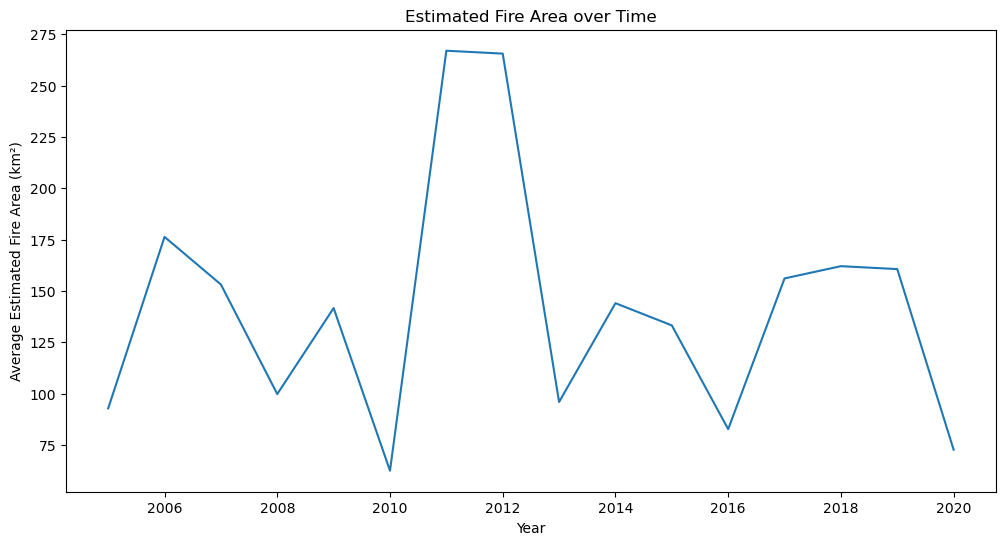

In [10]:
plt.figure(figsize=(12, 6))
df_new.plot(x=df_new.index, y=df_new.values)
plt.xlabel('Year')
plt.ylabel('Average Estimated Fire Area (km²)')
plt.title('Estimated Fire Area over Time')
plt.show()

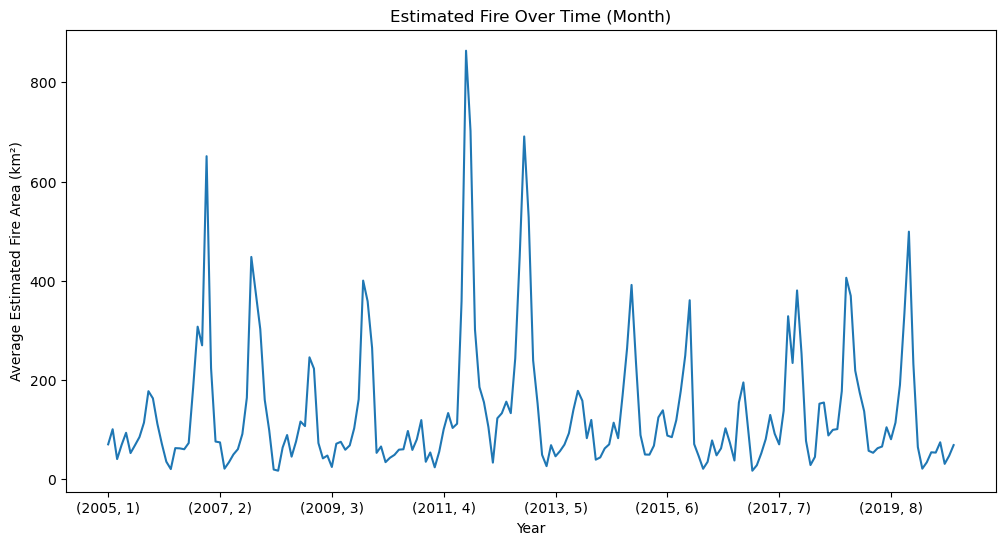

In [17]:
df1_new = wildfire_df.groupby(['Year','Month'])['Estimated_fire_area'].mean()

plt.figure(figsize= (12,6))
df1_new.plot(x=df1_new.index, y=df1_new.values)
plt.title('Estimated Fire Over Time (Month)')
plt.xlabel('Year')
plt.ylabel('Average Estimated Fire Area (km²)')
plt.show()




In [18]:
wildfire_df['Region'].unique()

array(['NSW', 'NT', 'QL', 'SA', 'TA', 'VI', 'WA'], dtype=object)

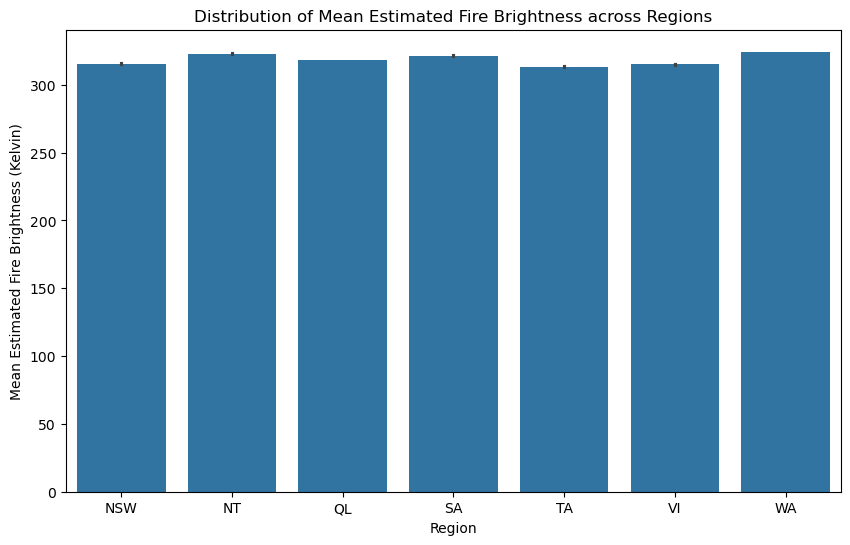

In [19]:
#TODO
# Creating a bar plot using seaborn to visualize the distribution of mean estimated fire brightness across regions
plt.figure(figsize=(10, 6))
# Using seaborn's barplot function to create the plot
sns.barplot(data=wildfire_df, x='Region', y='Mean_estimated_fire_brightness')
plt.xlabel('Region')
plt.ylabel('Mean Estimated Fire Brightness (Kelvin)')
plt.title('Distribution of Mean Estimated Fire Brightness across Regions')
plt.show()

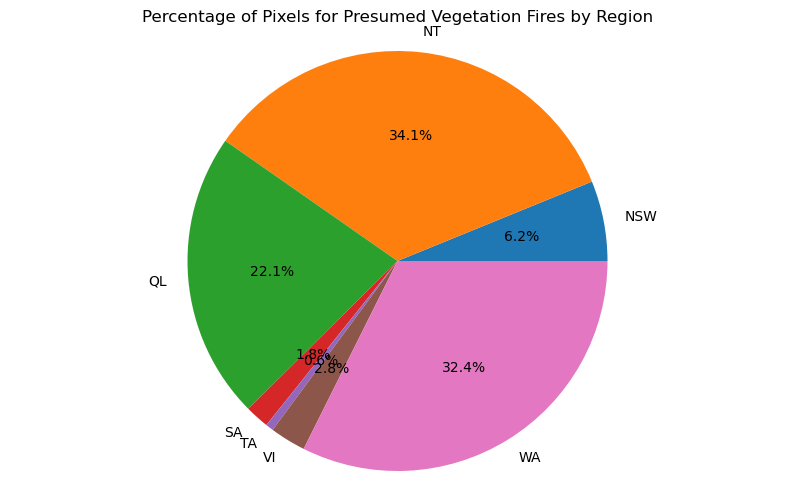

In [20]:
# Creating a pie chart to visualize the portion of count of pixels for presumed vegetation fires across regions
plt.figure(figsize=(10, 6))
# Grouping the data by region and summing the counts
region_counts = wildfire_df.groupby('Region')['Count'].sum()
# Creating the pie chart using plt.pie function
# Labels are set to the region names, and autopct is used to display percentage
plt.pie(region_counts, labels=region_counts.index, autopct='%1.1f%%')
plt.title('Percentage of Pixels for Presumed Vegetation Fires by Region')
plt.axis('equal')
plt.show()

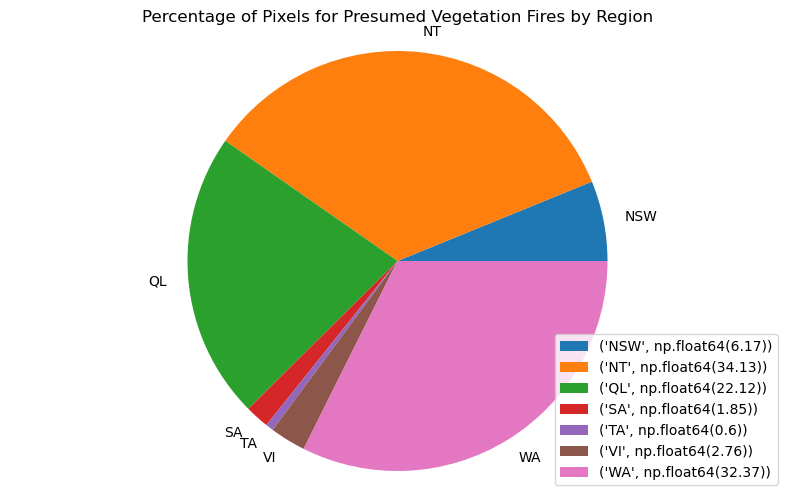

In [22]:
# Creating a pie chart to visualize the portion of count of pixels for presumed vegetation fires across regions
plt.figure(figsize=(10, 6))
# Grouping the data by region and summing the counts
region_counts = wildfire_df.groupby('Region')['Count'].sum()
# Creating the pie chart using plt.pie function
# Labels are set to the region names, and autopct is used to display percentage
plt.pie(region_counts, labels=region_counts.index,)
plt.title('Percentage of Pixels for Presumed Vegetation Fires by Region')
plt.legend([(i,round(k/region_counts.sum()*100,2)) for i,k in zip(region_counts.index, region_counts)])
plt.axis('equal')
plt.show()

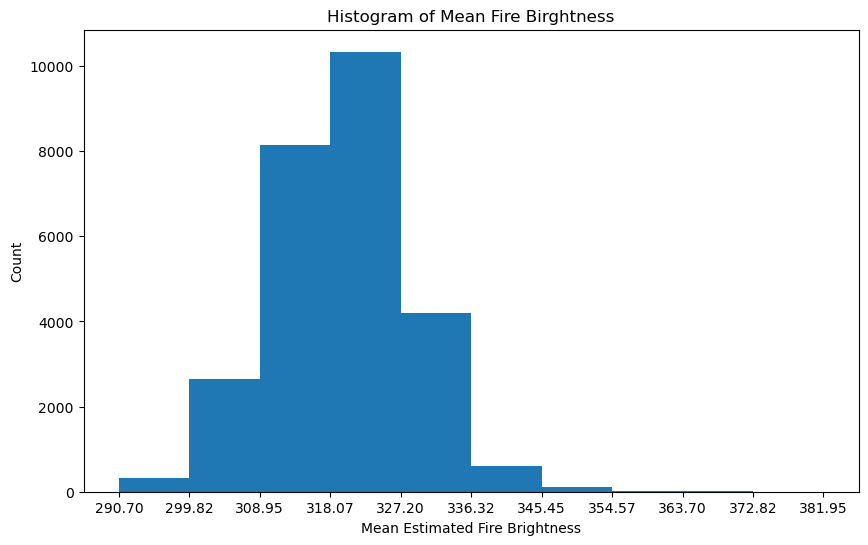

In [23]:
#TODO
plt.figure(figsize=(10, 6))
count, bin_edges = np.histogram(wildfire_df['Mean_estimated_fire_brightness'])

wildfire_df['Mean_estimated_fire_brightness'].plot(kind='hist',xticks = bin_edges)
plt.title('Histogram of Mean Fire Birghtness')
plt.xlabel('Mean Estimated Fire Brightness')
plt.ylabel('Count')
plt.show()

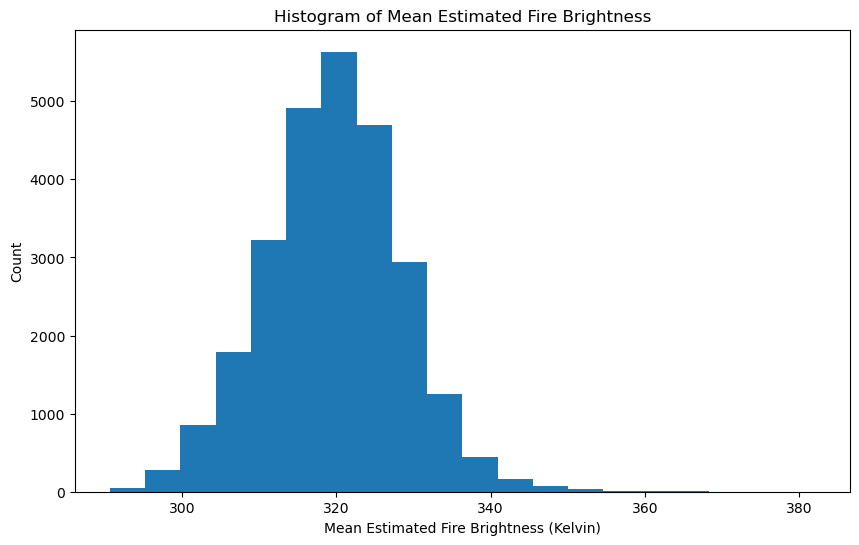

In [24]:
plt.figure(figsize=(10, 6))
# Using plt.hist to create the histogram
# Setting the number of bins to 20 for better visualization
plt.hist(x=wildfire_df['Mean_estimated_fire_brightness'], bins=20)
plt.xlabel('Mean Estimated Fire Brightness (Kelvin)')
plt.ylabel('Count')
plt.title('Histogram of Mean Estimated Fire Brightness')
plt.show()

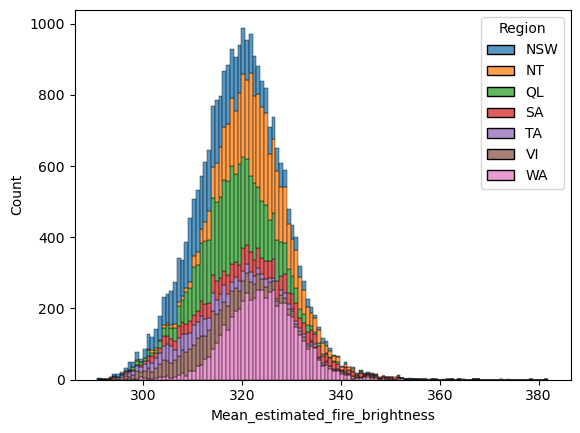

In [25]:
sns.histplot(data=wildfire_df, x='Mean_estimated_fire_brightness', hue='Region', multiple='stack')
plt.show()

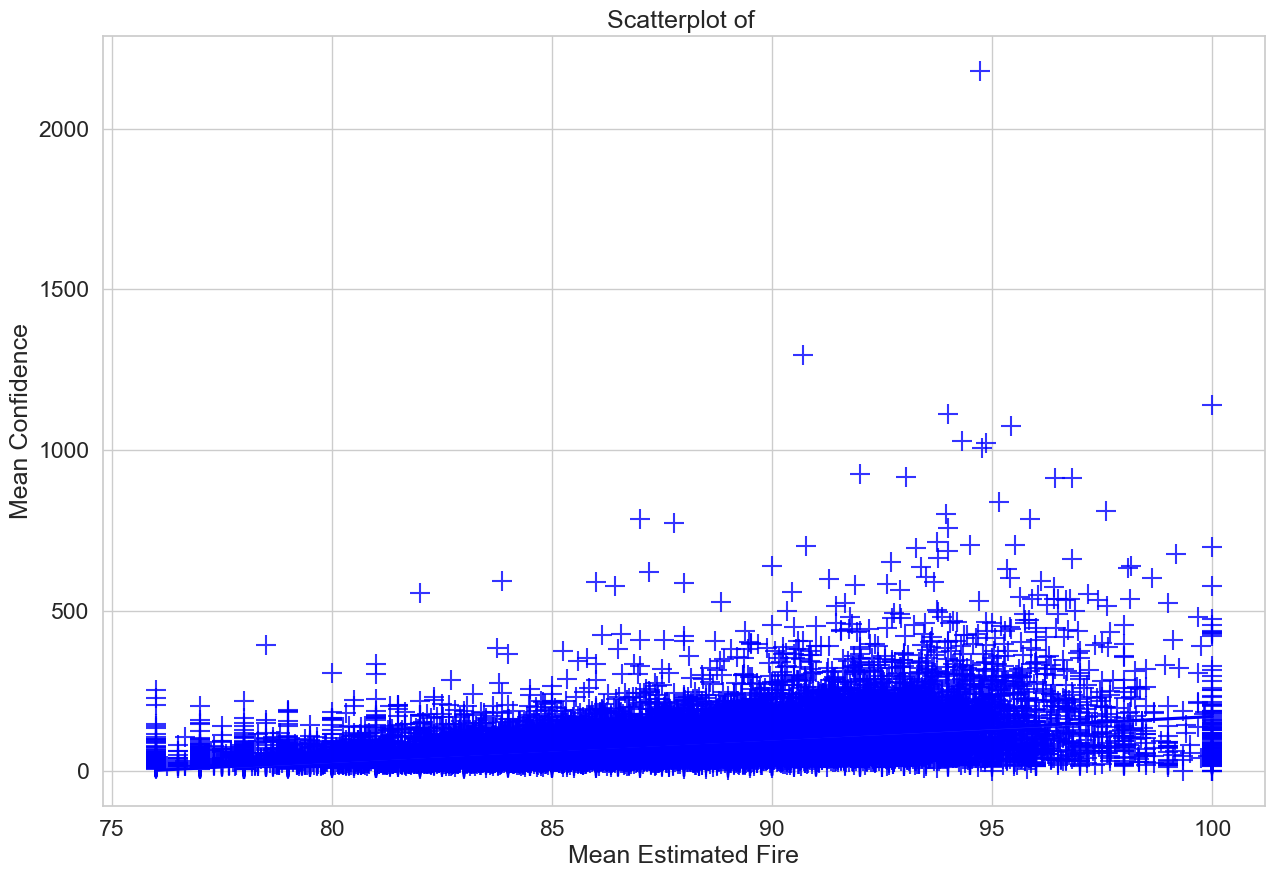

In [29]:
plt.figure(figsize=(15, 10))
sns.set(font_scale=1.5)
sns.set_style('whitegrid')  # change background to white background



ax = sns.regplot(data = wildfire_df,x = 'Mean_confidence',y = 'Mean_estimated_fire_radiative_power', color='blue', marker = '+',scatter_kws={'s': 200})

ax.set(xlabel='Mean Estimated Fire', ylabel='Mean Confidence') # add x- and y-labels
ax.set_title('Scatterplot of ') # add title
plt.show()

In [26]:
wildfire_df.head()

,Region,Date,Estimated_fire_area,Mean_estimated_fire_brightness,Mean_estimated_fire_radiative_power,Mean_confidence,Std_confidence,Var_confidence,Count,Replaced,Year,Month
0,NSW,1/4/2005,8.68000,312.266667,42.400000,78.666667,2.886751,8.333333,3,R,2005,1
1,NSW,1/5/2005,16.61125,322.475000,62.362500,85.500000,8.088793,65.428571,8,R,2005,1
2,NSW,1/6/2005,5.52000,325.266667,38.400000,78.333333,3.214550,10.333333,3,R,2005,1
3,NSW,1/7/2005,6.26400,313.870000,33.800000,92.200000,7.529940,56.700000,5,R,2005,1
4,NSW,1/8/2005,5.40000,337.383333,122.533333,91.000000,7.937254,63.000000,3,R,2005,1


In [43]:
wildfire_df.Mean_confidence[wildfire_df['Mean_confidence'] < 90]

0        78.666667
1        85.500000
2        78.333333
5        83.142857
8        87.769231
           ...    
26399    88.880000
26400    86.974359
26401    84.363636
26402    88.312500
26404    89.631579
Name: Mean_confidence, Length: 18640, dtype: float64

In [44]:
wildfire_df.loc[wildfire_df['Mean_confidence'] < 100, 'Mean_confidence']


0        78.666667
1        85.500000
2        78.333333
3        92.200000
4        91.000000
           ...    
26401    84.363636
26402    88.312500
26403    92.974359
26404    89.631579
26405    92.978723
Name: Mean_confidence, Length: 26213, dtype: float64

In [40]:
wildfire_df.Mean_confidence.describe()

count    26406.000000
mean        87.574735
std          4.371972
min         76.000000
25%         85.000000
50%         87.771429
75%         90.498403
max        100.000000
Name: Mean_confidence, dtype: float64

In [ ]:
# instantiate a feature group 
aus_reg = folium.map.FeatureGroup()

# Create a Folium map centered on Australia
Aus_map = folium.Map(location=[-25, 135], zoom_start=4)

# loop through the region and add to feature group
for lat, lng, lab in zip(reg.Lat, reg.Lon, reg.region):
    aus_reg.add_child(
        folium.features.CircleMarker(
            [lat, lng],
            popup=lab,
            radius=5, # define how big you want the circle markers to be
            color='red',
            fill=True,
            fill_color='blue',
            fill_opacity=0.6
        )
    )

# add incidents to map
Aus_map.add_child(aus_reg)